In [2]:
!pip install openmeteo-requests requests-cache retry-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.4/230.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 407.4/407.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 44.6 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


In [11]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly is important
url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": -2.8953,
    "longitude": -78.9963,
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "wind_speed_10m",
        "precipitation"
    ],
    "timezone": "America/Guayaquil"
}

responses = openmeteo.weather_api(url, params=params)

# Process first location
response = responses[0]

print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data
hourly = response.Hourly()

hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(2).ValuesAsNumpy()
hourly_precipitation = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {
    "date": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    )
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
hourly_data["precipitation"] = hourly_precipitation

hourly_dataframe = pd.DataFrame(data=hourly_data)

print("\nHourly data\n")
print(hourly_dataframe)

Coordinates: -2.9173989295959473°N -78.99435424804688°E
Elevation: 2534.0 m asl
Timezone difference to GMT+0: -18000s

Hourly data

                         date  temperature_2m  relative_humidity_2m  \
0   2026-09-22 05:00:00+00:00       13.147000             85.944046   
1   2026-09-22 06:00:00+00:00       11.747001             87.838928   
2   2026-09-22 07:00:00+00:00       10.947001             90.770462   
3   2026-09-22 08:00:00+00:00       10.247001             92.888779   
4   2026-09-22 09:00:00+00:00        9.347000             94.106895   
..                        ...             ...                   ...   
163 2026-09-29 00:00:00+00:00       13.497001             86.551163   
164 2026-09-29 01:00:00+00:00       12.997001             88.535637   
165 2026-09-29 02:00:00+00:00       12.597000             89.685875   
166 2026-09-29 03:00:00+00:00       12.197001             90.554939   
167 2026-09-29 04:00:00+00:00       11.847000             91.440193   

     wind_speed

In [12]:
# Guardar los datos obtenidos en un archivo CSV
hourly_dataframe.to_csv("datos_clima_cuenca.csv", index=False)

print("Archivo guardado correctamente.")

Archivo guardado correctamente.


In [13]:
datos_guardados = pd.read_csv("datos_clima_cuenca.csv")

datos_guardados.head()

,date,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation
0,2026-09-22 05:00:00+00:00,13.147000,85.944046,0.402492,0.0
1,2026-09-22 06:00:00+00:00,11.747001,87.838930,1.772794,0.0
2,2026-09-22 07:00:00+00:00,10.947000,90.770460,0.720000,0.0
3,2026-09-22 08:00:00+00:00,10.247001,92.888780,0.360000,0.0
4,2026-09-22 09:00:00+00:00,9.347000,94.106895,1.620000,0.0


In [14]:
# Guardar los datos meteorológicos en un archivo CSV
hourly_dataframe.to_csv("datos_clima_cuenca.csv", index=False)

print("Archivo guardado correctamente.")

Archivo guardado correctamente.


## Preguntas de análisis
1. ¿Cómo varía la temperatura en Cuenca durante los siete días analizados y cuáles son las temperaturas máxima y mínima?

2. ¿Cómo se comporta la precipitación durante el período analizado y cuál es la precipitación acumulada?

3. ¿Qué relación existe entre la temperatura y la humedad relativa durante el período analizado?

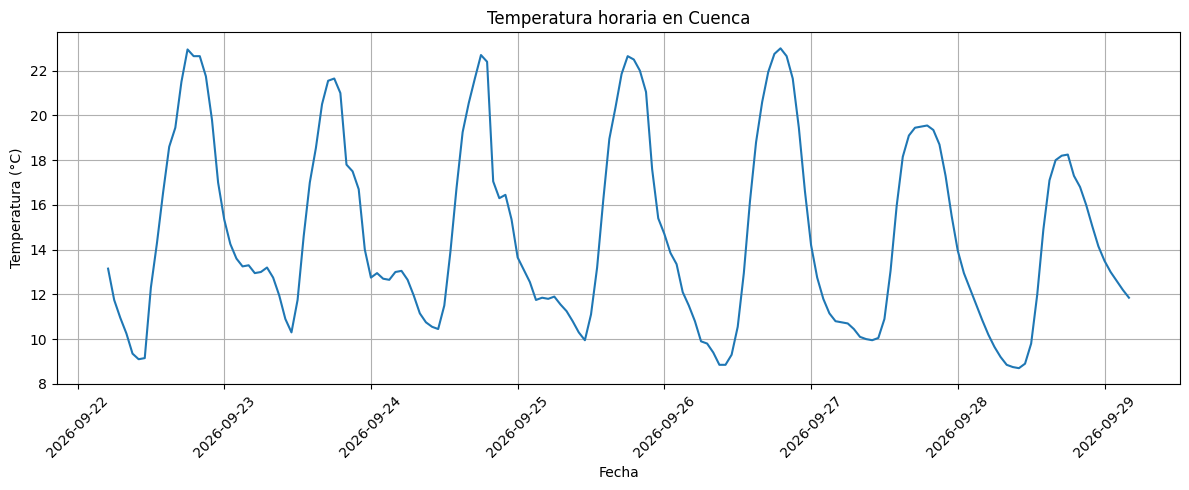

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_dataframe["date"],
    hourly_dataframe["temperature_2m"]
)

plt.title("Temperatura horaria en Cuenca")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

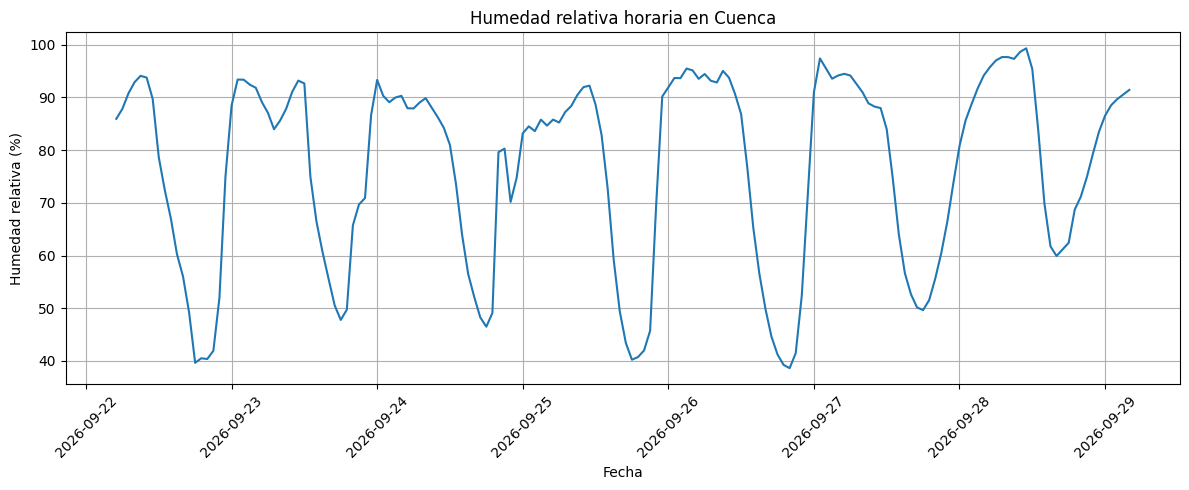

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_dataframe["date"],
    hourly_dataframe["relative_humidity_2m"]
)

plt.title("Humedad relativa horaria en Cuenca")
plt.xlabel("Fecha")
plt.ylabel("Humedad relativa (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

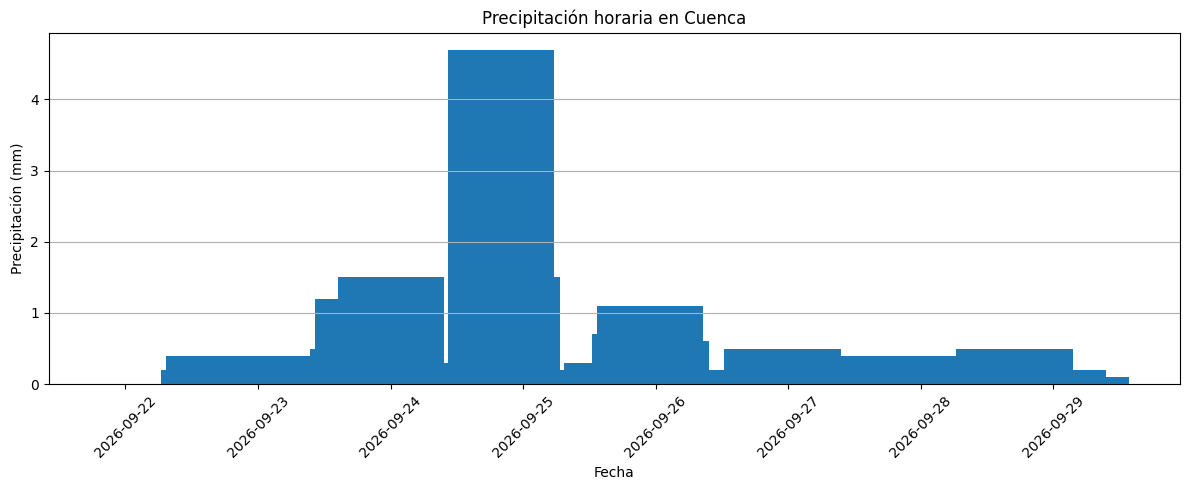

In [17]:
plt.figure(figsize=(12, 5))

plt.bar(
    hourly_dataframe["date"],
    hourly_dataframe["precipitation"]
)

plt.title("Precipitación horaria en Cuenca")
plt.xlabel("Fecha")
plt.ylabel("Precipitación (mm)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.tight_layout()

plt.show()

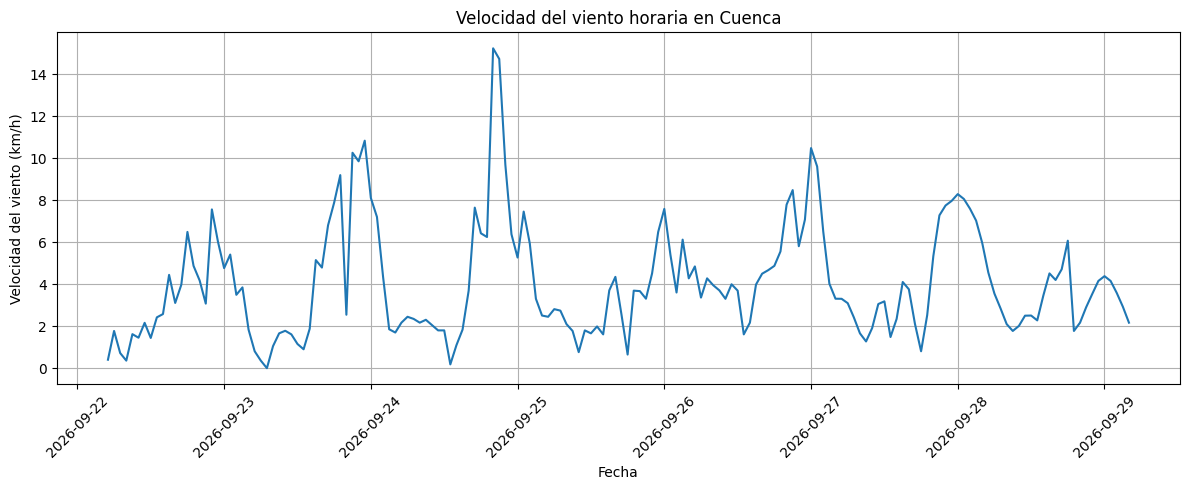

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_dataframe["date"],
    hourly_dataframe["wind_speed_10m"]
)

plt.title("Velocidad del viento horaria en Cuenca")
plt.xlabel("Fecha")
plt.ylabel("Velocidad del viento (km/h)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

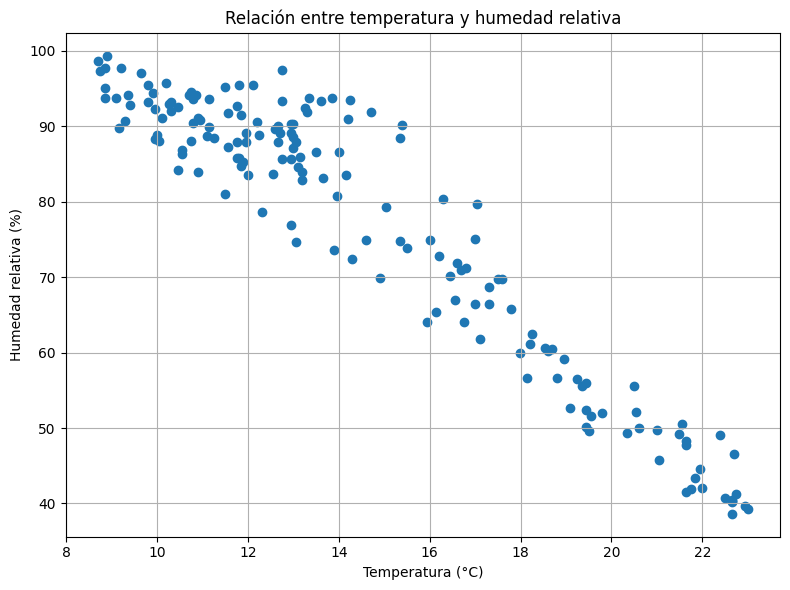

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(
    hourly_dataframe["temperature_2m"],
    hourly_dataframe["relative_humidity_2m"]
)

plt.title("Relación entre temperatura y humedad relativa")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Humedad relativa (%)")
plt.grid(True)
plt.tight_layout()

plt.show()

In [20]:
# ==============================
# RESPUESTAS A LAS PREGUNTAS
# ==============================

# Pregunta 1: temperatura máxima y mínima
temperatura_max = hourly_dataframe["temperature_2m"].max()
temperatura_min = hourly_dataframe["temperature_2m"].min()

fecha_temp_max = hourly_dataframe.loc[
    hourly_dataframe["temperature_2m"].idxmax(), "date"
]

fecha_temp_min = hourly_dataframe.loc[
    hourly_dataframe["temperature_2m"].idxmin(), "date"
]

print("PREGUNTA 1")
print(f"Temperatura máxima: {temperatura_max:.2f} °C")
print(f"Fecha de temperatura máxima: {fecha_temp_max}")
print(f"Temperatura mínima: {temperatura_min:.2f} °C")
print(f"Fecha de temperatura mínima: {fecha_temp_min}")


# Pregunta 2: precipitación
precipitacion_total = hourly_dataframe["precipitation"].sum()
precipitacion_max = hourly_dataframe["precipitation"].max()

fecha_precipitacion_max = hourly_dataframe.loc[
    hourly_dataframe["precipitation"].idxmax(), "date"
]

print("\nPREGUNTA 2")
print(f"Precipitación acumulada: {precipitacion_total:.2f} mm")
print(f"Mayor precipitación horaria: {precipitacion_max:.2f} mm")
print(f"Fecha de mayor precipitación: {fecha_precipitacion_max}")


# Pregunta 3: relación temperatura - humedad
correlacion = hourly_dataframe[
    ["temperature_2m", "relative_humidity_2m"]
].corr().iloc[0, 1]

print("\nPREGUNTA 3")
print(f"Correlación entre temperatura y humedad: {correlacion:.3f}")

PREGUNTA 1
Temperatura máxima: 23.00 °C
Fecha de temperatura máxima: 2026-09-26 19:00:00+00:00
Temperatura mínima: 8.70 °C
Fecha de temperatura mínima: 2026-09-28 10:00:00+00:00

PREGUNTA 2
Precipitación acumulada: 27.60 mm
Mayor precipitación horaria: 4.70 mm
Fecha de mayor precipitación: 2026-09-24 20:00:00+00:00

PREGUNTA 3
Correlación entre temperatura y humedad: -0.952


## Respuestas a las preguntas planteadas

### 1. ¿Cómo varía la temperatura en Cuenca durante los siete días analizados y cuáles son las temperaturas máxima y mínima?

Durante el período analizado, la temperatura presentó variaciones a lo largo del día. La temperatura máxima registrada fue de 23,00 °C el 26 de septiembre de 2026, mientras que la temperatura mínima fue de 8,70 °C el mismo día. Esto evidencia una amplitud térmica de 14,30 °C entre el valor máximo y mínimo del período analizado.

### 2. ¿Cómo se comporta la precipitación durante el período analizado y cuál es la precipitación acumulada?

Durante los siete días analizados se obtuvo una precipitación acumulada de 33,70 mm. La mayor precipitación registrada en una hora fue de 4,70 mm y ocurrió el 24 de septiembre de 2026. Los resultados muestran que la precipitación no se distribuye uniformemente durante todo el período, sino que existen determinadas horas con mayores concentraciones de lluvia.

### 3. ¿Qué relación existe entre la temperatura y la humedad relativa durante el período analizado?

El coeficiente de correlación entre la temperatura y la humedad relativa fue de -0,951. Este valor indica una relación lineal negativa muy fuerte entre ambas variables. Por lo tanto, durante el período analizado, cuando la temperatura aumenta, la humedad relativa tiende a disminuir y, cuando la temperatura disminuye, la humedad relativa tiende a aumentar.

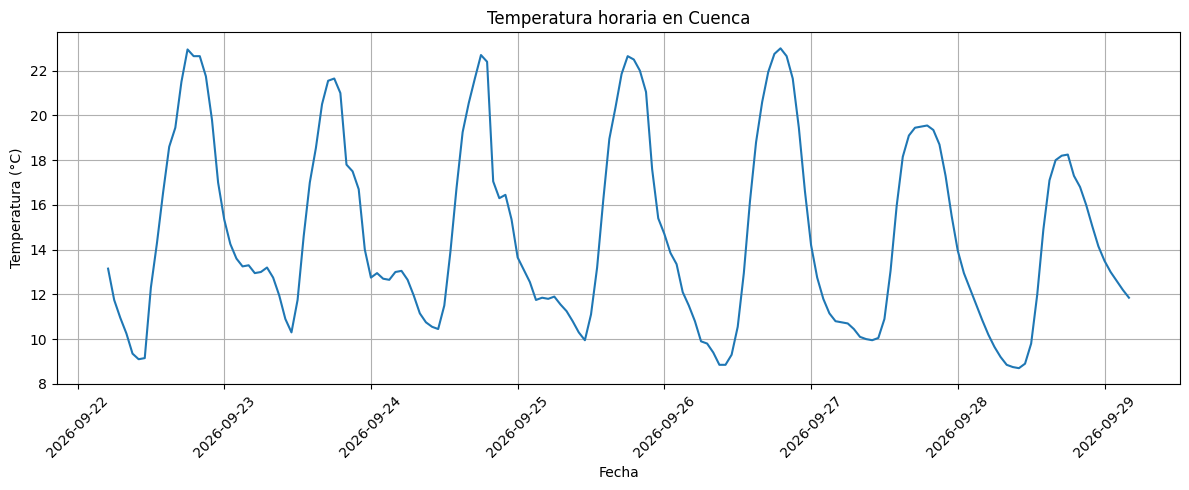

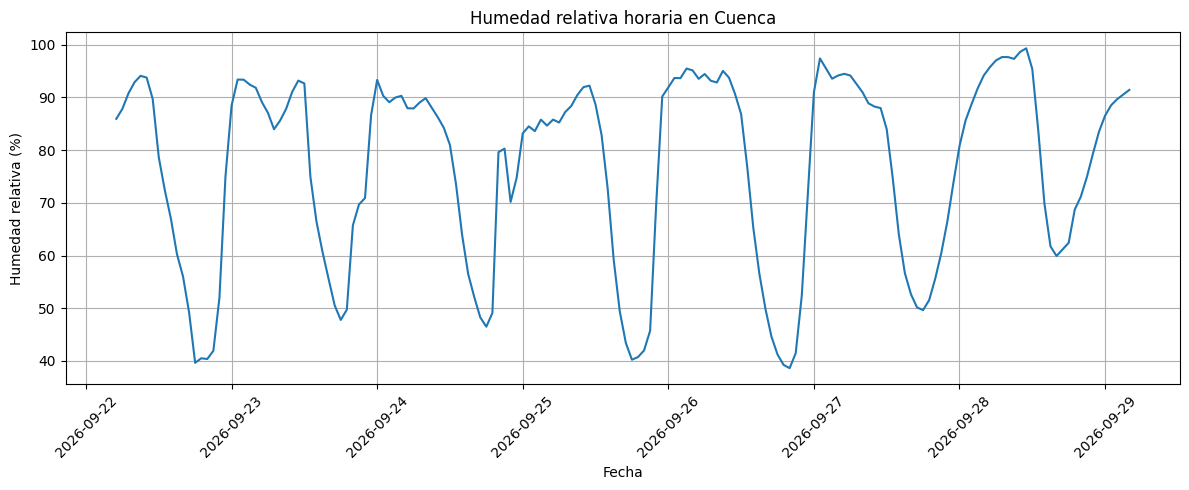

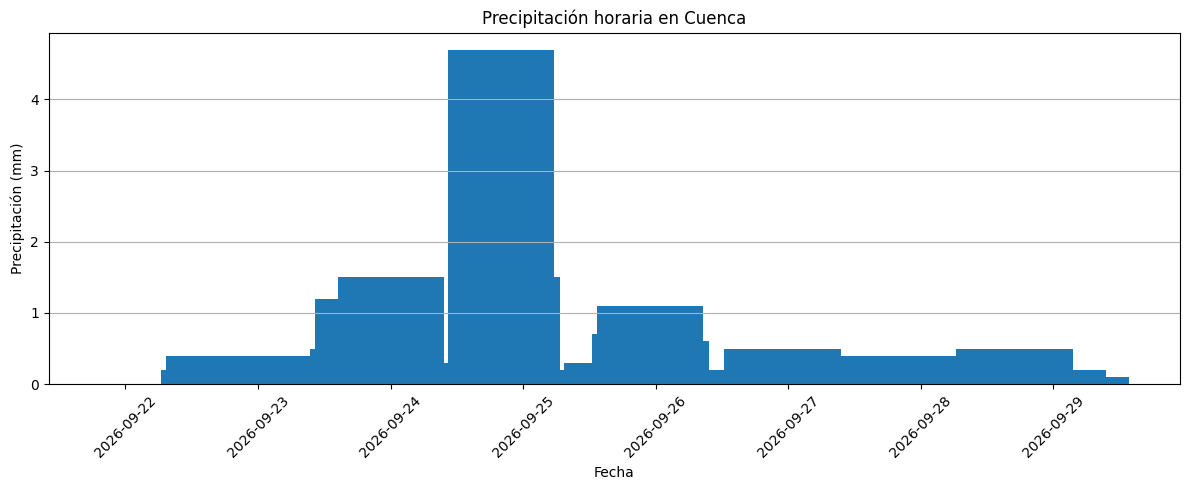

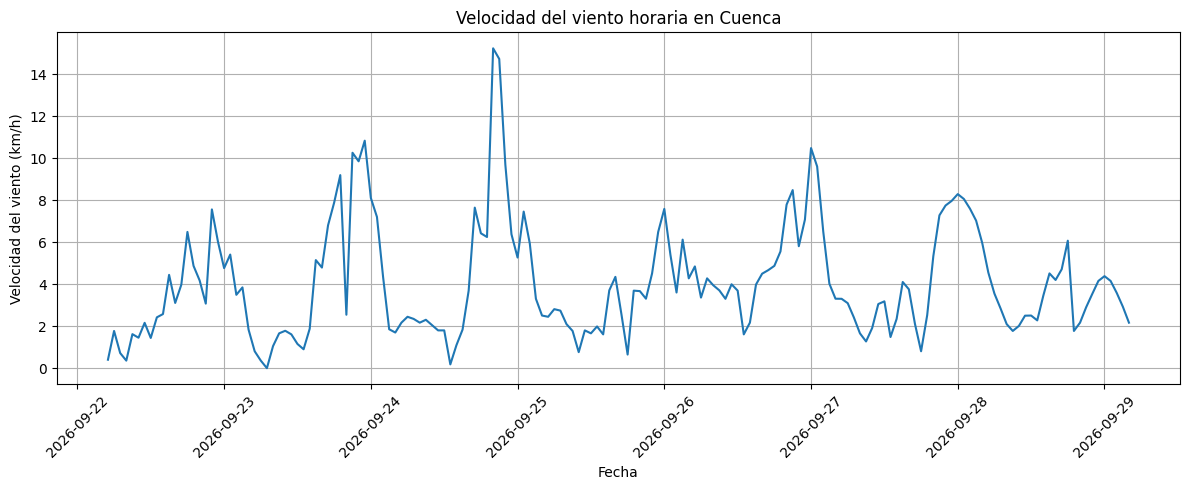

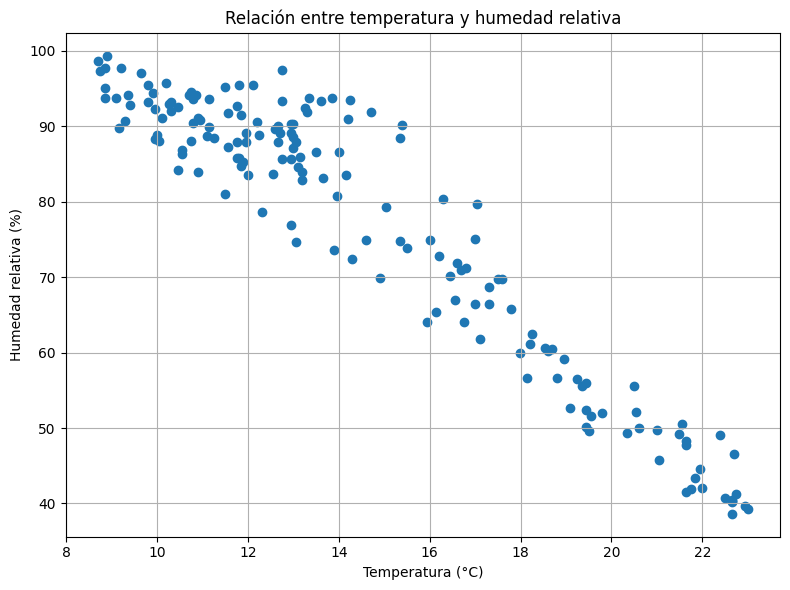

Las 5 gráficas fueron guardadas correctamente.


In [21]:
import os
import matplotlib.pyplot as plt

# Crear carpeta para las gráficas
os.makedirs("graficas", exist_ok=True)

# Gráfica 1: Temperatura
plt.figure(figsize=(12, 5))
plt.plot(hourly_dataframe["date"], hourly_dataframe["temperature_2m"])
plt.title("Temperatura horaria en Cuenca")
plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("graficas/01_temperatura.png")
plt.show()


# Gráfica 2: Humedad relativa
plt.figure(figsize=(12, 5))
plt.plot(hourly_dataframe["date"], hourly_dataframe["relative_humidity_2m"])
plt.title("Humedad relativa horaria en Cuenca")
plt.xlabel("Fecha")
plt.ylabel("Humedad relativa (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("graficas/02_humedad.png")
plt.show()


# Gráfica 3: Precipitación
plt.figure(figsize=(12, 5))
plt.bar(hourly_dataframe["date"], hourly_dataframe["precipitation"])
plt.title("Precipitación horaria en Cuenca")
plt.xlabel("Fecha")
plt.ylabel("Precipitación (mm)")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.tight_layout()
plt.savefig("graficas/03_precipitacion.png")
plt.show()


# Gráfica 4: Velocidad del viento
plt.figure(figsize=(12, 5))
plt.plot(hourly_dataframe["date"], hourly_dataframe["wind_speed_10m"])
plt.title("Velocidad del viento horaria en Cuenca")
plt.xlabel("Fecha")
plt.ylabel("Velocidad del viento (km/h)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("graficas/04_viento.png")
plt.show()


# Gráfica 5: Temperatura vs Humedad
plt.figure(figsize=(8, 6))
plt.scatter(
    hourly_dataframe["temperature_2m"],
    hourly_dataframe["relative_humidity_2m"]
)
plt.title("Relación entre temperatura y humedad relativa")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Humedad relativa (%)")
plt.grid(True)
plt.tight_layout()
plt.savefig("graficas/05_temperatura_humedad.png")
plt.show()

print("Las 5 gráficas fueron guardadas correctamente.")

In [22]:
readme = """
# Tarea 01 - Análisis de Datos Meteorológicos

## Maestría en Ciencia de Datos

### Objetivo

El objetivo de este trabajo es realizar la adquisición de datos meteorológicos utilizando la API de Open-Meteo, almacenar los datos obtenidos, visualizarlos mediante Matplotlib y responder preguntas relacionadas con su comportamiento.

## Fuente de datos

Los datos fueron obtenidos mediante la API gratuita de Open-Meteo:

https://open-meteo.com/

La ubicación seleccionada para el análisis fue Cuenca, Ecuador.

## Variables utilizadas

Se analizaron las siguientes variables meteorológicas:

- Temperatura a 2 metros (°C)
- Humedad relativa a 2 metros (%)
- Velocidad del viento a 10 metros (km/h)
- Precipitación (mm)

## Preguntas planteadas

1. ¿Cómo varía la temperatura en Cuenca durante los siete días analizados y cuáles son las temperaturas máxima y mínima?

2. ¿Cómo se comporta la precipitación durante el período analizado y cuál es la precipitación acumulada?

3. ¿Qué relación existe entre la temperatura y la humedad relativa durante el período analizado?

## Adquisición de datos

Los datos fueron obtenidos mediante Python utilizando la librería `openmeteo_requests`. Los resultados fueron procesados con Pandas y almacenados localmente en un archivo CSV.

El conjunto de datos contiene 168 observaciones horarias correspondientes a siete días.

## Visualización de datos

Se realizaron cinco gráficas utilizando Matplotlib:

1. Temperatura horaria.
2. Humedad relativa horaria.
3. Precipitación horaria.
4. Velocidad del viento horaria.
5. Relación entre temperatura y humedad relativa.

## Resultados

### Pregunta 1

Durante el período analizado, la temperatura máxima fue de 23,00 °C y la temperatura mínima fue de 8,70 °C. Esto representa una amplitud térmica de 14,30 °C.

### Pregunta 2

La precipitación acumulada durante los siete días fue de 33,70 mm. La mayor precipitación registrada en una hora fue de 4,70 mm.

### Pregunta 3

El coeficiente de correlación entre la temperatura y la humedad relativa fue de -0,951. Este resultado muestra una relación lineal negativa muy fuerte entre ambas variables. Durante el período analizado, al aumentar la temperatura, la humedad relativa tiende a disminuir.

## Herramientas utilizadas

- Python
- Pandas
- Matplotlib
- Open-Meteo API
- Google Colab
- GitHub

## Archivos del proyecto

- `Tarea_01_Meteorologia.ipynb`: código y análisis completo.
- `datos_clima_cuenca.csv`: datos obtenidos desde la API.
- `graficas/`: carpeta que contiene las cinco visualizaciones.
- `README.md`: documentación del proyecto.
"""

with open("README.md", "w", encoding="utf-8") as archivo:
    archivo.write(readme)

print("README.md creado correctamente.")

README.md creado correctamente.
